Supongamos que la densidad lineal de la cuerda se comporta como una exponencial:
$$\rho(x) = e^{\alpha x}$$
La velocidad de movimiento de la cuerda depende de la tensión:
$$ v = \sqrt{\frac{T(x)}{\rho(x)}} $$
$$\frac{dT}{dx}\frac{\partial y}{\partial x} + T \frac{\partial^2 y}{\partial x ^2} = \rho\frac{\partial^2 y}{\partial t^2}$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

L = 1.0
nx = 200
dx = L / (nx -1)

#parámetros físicos
rho0 = 0.01
T0 = 40.0
alfa = 0.5
kappa = 0

#malla
x = np.linspace(0, L, nx)

In [2]:
modelo  = "exponencial" # "Catenaria"

if modelo == "exponencial":
    rho = rho0 * np.exp(alfa * x)
    T = T0 * np.exp(alfa * x)

elif modelo == "catenaria":
    g = 9.8
    rho = rho0 * np.ones_like(x)
    T = T0 * np.cosh(rho0 * g * x / T0)

In [3]:
v = np.sqrt(T / rho)
vmax = np.max(v)

#condición de estabilidad
dt = 0.4 * dx / vmax

print("dt = ", dt)

y = np.exp(-200 * (x - 0.5) ** 2) #pulso gaussiano
y_old = y.copy()
y_new = np.zeros(nx)

dt =  3.178168502681788e-05


In [4]:
def step():
    global y, y_old, y_new
    
    for i in range(1, nx -1):
        T_ip = 0.5 * (T[i] + T[i + 1])
        T_im = 0.5 * (T[i] + T[i - 1])

        lap = (T_ip * (y[i + 1] - y[i]) - T_im * (y[i] - y[i -1])) /  dx ** 2

        y_new[i] = (2 * y[i] - y_old[i] + dt ** 2 / rho[i] - kappa * dt * (y[i] - y_old[i]))

    y_new[0] = 0
    y_new[-1] = 0

    y_old[:] = y[:]
    y[:] = y_new[:]

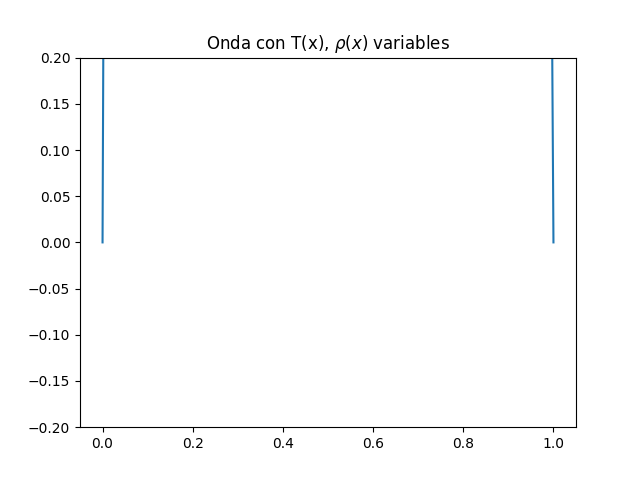

In [6]:
%matplotlib widget
fig, ax = plt.subplots()

line, = ax.plot(x, y)
ax.set_ylim(-0.2, 0.2)
ax.set_title(r"Onda con T(x), $\rho (x)$ variables")

def update(frame):
    for _ in range(5):
        step()
    line.set_ydata(y)
    return line,

#ani = FuncAnimation(fig, update, frames = 1000, interval = 20)
plt.show()